# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  Group 16

Created by Hrishikesh Giri (017867668), Srihan Cheemangunta (017055766), Yeqing Xu (017746079)  
Last updated: 3/29/2026  

In [ ]:
# Import dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Define the list of seasons we want to collect
seasons = ["2024-25", "2025-26"]

all_dfs = []

# 2. Loop through each season and read the data
for season in seasons:
    # Construct the URL dynamically
    url = f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/gws/merged_gw.csv"

    try:
        # Some older files might need 'latin-1' encoding
        temp_df = pd.read_csv(url, encoding='utf-8')
    except UnicodeDecodeError:
        temp_df = pd.read_csv(url, encoding='latin-1')
    except Exception as e:
        print(f"Could not download data for {season}: {e}")
        continue

    # 3. Add a season column so you can distinguish the data later
    temp_df['season'] = season

    # Append to our list
    all_dfs.append(temp_df)
    print(f"Successfully loaded {season}")

# 4. Combine all DataFrames into one
df_combined = pd.concat(all_dfs, ignore_index=True)

# View the result
print(f"\nFinal combined shape: {df_combined.shape}")
print(df_combined['season'].value_counts())
df_combined.head()

Successfully loaded 2024-25
Successfully loaded 2025-26

Final combined shape: (49958, 54)
season
2024-25    27605
2025-26    22353
Name: count, dtype: int64


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,season,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,0,50,False,0,1,2024-25,NaN,NaN,NaN,NaN
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0,45,True,0,1,2024-25,NaN,NaN,NaN,NaN
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,0,50,True,0,1,2024-25,NaN,NaN,NaN,NaN
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,0,45,False,0,1,2024-25,NaN,NaN,NaN,NaN
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,0,55,False,1,1,2024-25,NaN,NaN,NaN,NaN


In [ ]:
# Drop the 7 mng_* columns
columns_to_drop = [
    'mng_clean_sheets',
    'mng_draw',
    'mng_goals_scored',
    'mng_loss',
    'mng_underdog_draw',
    'mng_underdog_win',
    'mng_win'
]

df_combined.drop(columns=columns_to_drop, inplace=True)

print(f"Columns dropped. New shape of df_combined: {df_combined.shape}")
print("Remaining columns:")
print(df_combined.columns.tolist())

Columns dropped. New shape of df_combined: (49958, 47)
Remaining columns:
['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'modified', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'GW', 'season', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles']


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49958 entries, 0 to 49957
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name                             49958 non-null  object 
 1   position                         49958 non-null  object 
 2   team                             49958 non-null  object 
 3   xP                               49958 non-null  float64
 4   assists                          49958 non-null  int64  
 5   bonus                            49958 non-null  int64  
 6   bps                              49958 non-null  int64  
 7   clean_sheets                     49958 non-null  int64  
 8   creativity                       49958 non-null  float64
 9   element                          49958 non-null  int64  
 10  expected_assists                 49958 non-null  float64
 11  expected_goal_involvements       49958 non-null  float64
 12  expected_goals    

In [ ]:
# df_original = df_combined.copy()

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

The dataset is mostly clean. We dropped 7 `mng_*` fields which are mostly unusable for this project. We now have a two-season (`2024-25` and `2025-26`) combined dataset with 49,958 rows and 47 columns, and almost every retained column is fully populated. However, there's a schema mismatch across seasons. We have missing values in columns `clearances_blocks_interceptions`, `defensive_contribution`, `recoveries`, and `tackles` for all `2024-25` season, because those features only exist in `2025-26`.

Another formatting concers is that `kickoff_time` is still stored as an object string, so we would convert it to a proper datetime before analysis. Additionally, fields like `element`, `fixture`, and `opponent_team` are numeric IDs, so if we want to use them for readable plots, we would map those to labels.

Our next cleaning plan would be:


1.   Convert `kickoff_time` to datetime
2.   Standardize categorical columns, for example `team`, `position`, `name`, if needed. Make sure there's no whitespace or naming inconsistencies before plotting.
3.   Decide how to handle the 4 season-specific defensive columns: keep them and limit analyses using them to `2025-26`, or exclude them when doing cross-season comparisons.



In [ ]:
# Convert kickoff_time to datetime
df_combined['kickoff_time'] = pd.to_datetime(
    df_combined['kickoff_time'],
    errors="coerce")

# Verify datatype
print(df_combined["kickoff_time"].dtype)

datetime64[ns, UTC]


In [ ]:
# Standardize categorical columns
categorical_cols = ["team", "position", "season", "name"]

# Remove extra spaces
for col in categorical_cols:
      df_combined[col] = df_combined[col].astype(str).str.strip()

# Make positions consistent like GK, DEF, MID, FWD
df_combined["position"] = df_combined["position"].str.upper()

# Store them as categorical variables for cleaner analysis
for col in categorical_cols:
      df_combined[col] = df_combined[col].astype("category")


In [ ]:
df_combined.info()
df_combined.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49958 entries, 0 to 49957
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   name                             49958 non-null  category           
 1   position                         49958 non-null  category           
 2   team                             49958 non-null  category           
 3   xP                               49958 non-null  float64            
 4   assists                          49958 non-null  int64              
 5   bonus                            49958 non-null  int64              
 6   bps                              49958 non-null  int64              
 7   clean_sheets                     49958 non-null  int64              
 8   creativity                       49958 non-null  float64            
 9   element                          49958 non-null  int64              
 10

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,season,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,0,50,False,0,1,2024-25,NaN,NaN,NaN,NaN
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0,45,True,0,1,2024-25,NaN,NaN,NaN,NaN
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,0,50,True,0,1,2024-25,NaN,NaN,NaN,NaN
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,0,45,False,0,1,2024-25,NaN,NaN,NaN,NaN
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,0,55,False,1,1,2024-25,NaN,NaN,NaN,NaN


### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

Unique question: How do contextual factors such as home/away status affect player output?

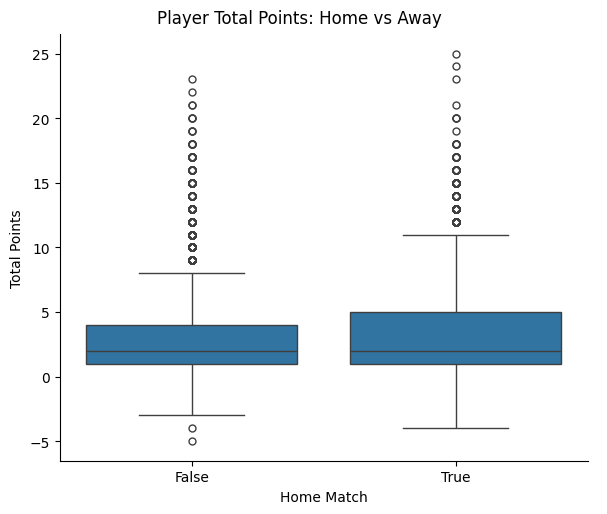

In [ ]:
# Your code here . . .
# Use was_home as a category, compared against total_points

# Filter the dataset to only include players who played for at least 30 minutes
df_active_players = df_combined[df_combined['minutes'] >= 30]


g = sns.catplot(
      data=df_active_players,
      x="was_home",
      y="total_points",
      kind="box",
      height=5,
      aspect=1.2
  )

g.set_axis_labels("Home Match", "Total Points")
g.fig.suptitle("Player Total Points: Home vs Away", y=1.02)
plt.show()

The median line inside both boxes sits exactly at 2 points, indicating that a player's baseline expectation remains consistent whether they play at home or away. However, the potential point ceiling is higher for home matches. Specifically, the 75th percentile and the upper whisker reach higher values for home games compared to away games.

### Q3: Come up with a another unique question. This question must use map() or apply()

Unique question: Does opponent difficulty affect a player’s total points?

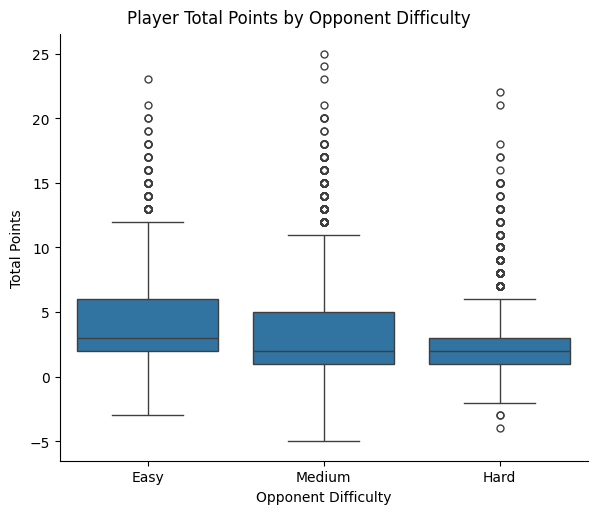

In [ ]:
# Your code here . . .
# To answer this question, we need to import team.csv to map opponent_team IDs to their actual team names
teams_2425 = pd.read_csv("https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2024-25/teams.csv")
teams_2526 = pd.read_csv("https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2025-26/teams.csv")

# Keep only the columns needed for the merge
teams_2425 = teams_2425[["id", "name", "strength"]].copy()
teams_2526 = teams_2526[["id", "name", "strength"]].copy()

# Add season so the merge matches the right year
teams_2425["season"] = "2024-25"
teams_2526["season"] = "2025-26"
teams_all = pd.concat([teams_2425, teams_2526], ignore_index=True)

# Rename for clarity before merging
teams_all = teams_all.rename(columns={
    "id": "opponent_team",
    "name": "opponent_name",
    "strength": "opponent_strength"
})

# Merge opponent info onto the player-gameweek table
df_plot = df_combined.merge(
    teams_all,
    on=["season", "opponent_team"],
    how="left"
)
# df_plot.head()

# create a categorical difficulty label with apply()
def label_difficulty(strength):
      if strength <= 2:
          return "Easy"
      elif strength == 3:
          return "Medium"
      else:
          return "Hard"

df_plot["opponent_difficulty"] = df_plot["opponent_strength"].apply(label_difficulty)
# df_plot.head()

# Filter the dataset to only include players who played for at least 30 minutes
df_active_players = df_plot[df_plot["minutes"] >= 30]
g = sns.catplot(
      data=df_active_players,
      x="opponent_difficulty",
      y="total_points",
      kind="box",
      order=["Easy", "Medium", "Hard"],
      height=5,
      aspect=1.2
  )
g.set_axis_labels("Opponent Difficulty", "Total Points")
g.fig.suptitle("Player Total Points by Opponent Difficulty", y=1.02)
plt.show()

Opponent difficulty clearly restricts player point potential. While the median score only drops slightly from 3 points against 'Easy' teams to 2 points against 'Medium' and 'Hard' teams, the point ceiling is heavily compressed. Against 'Hard' opponents, the 75th percentile is just 3 points, showing that high-scoring returns are less likely against top-tier teams.

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
# Your code here . . .
df_active = df_plot[df_plot["minutes"] >= 30].copy()
df_active["position"] = df_active["position"].str.replace("GKP", "GK")
df_active["Home/Away"] = df_active["was_home"].map({True: "Home", False: "Away"})

fig = px.box(
    df_active,
    x="opponent_difficulty",
    y="total_points",
    color="Home/Away",
    facet_col="position",
    category_orders={
        "opponent_difficulty": ["Easy", "Medium", "Hard"],
        "position": ["GK", "DEF", "MID", "FWD"],
    },
    points="outliers",
    title="Total Points by Opponent Difficulty, Home/Away, and Position",
    labels={"opponent_difficulty": "Opponent Difficulty", "total_points": "Total Points"},
)

fig.show()

This question combines both the previous questions and makes it into an interactive plot. This helps the audience directly compare home and away performance across different opponent difficulties in a single view, and by clicking the legend, they can isolate either home or away games to focus on one factor at a time.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

Additional dataset needed would be to have a synthetic data for defensive_contribution, clearances_blocks_interceptions,recoveries, and tackles since these stats were collected starting the 25-26 season and never before that. This would help to see players in defenive roles getting more points and being able to compete better with attacking players, who generally tend to have higher points. The dataset can be directly combined by simply filling in the null values in combined seasons dataset and you would not need to reshape it.  


Another additional dataset we need to bring in is `teams.csv`. The main dataset only provides an integer ID for `opponent_team` (e.g., 1, 2, 3), which is unreadable. The `teams.csv` data strengthens our argument by providing the actual team names and their official "strength" ratings, allowing us to categorize opponents by difficulty.

We introduced this `teams.csv` in Question 3. We loaded both the `2024-25` and `2025-26` `teams.csv` files and concatenate them into one master teams table. Then, we used a left merge to combine this master teams table with our main player dataset. We joined them on a composite key using `season` and `opponent_team` to ensure we map the correct team ID.

For reshaping our data, we dropped unnecessary columns from the `teams.csv` data, keeping only `id`, `name`, and `strength`. We added a `season` column to both team dataframes and renamed the `id` column in the teams table to `opponent_team` so it shares the exact same column name as the main dataset.